In [1]:
import os

# Core LSD imports
from sclsd.core import LSDConfig
from sclsd.train import LSD
from sclsd.plotting import plot_random_walks
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state

from sclsd.preprocessing import get_prior_transition
# Scientific computing
import pandas as pd

# Deep learning
import torch


# Single-cell analysis
import scanpy as sc

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set random seeds for reproducibility
SEED = 42
set_all_seeds(SEED)

In [3]:
adata = sc.read("../../Zenodo/Pancreas/preprocessed_adata.h5ad")
#remove cell types fev+ alpha and fev+ beta
clusters_to_remove = ["Fev+ Alpha", "Fev+ Beta"]
mask = ~(adata.obs["clusters"].isin(clusters_to_remove))
missing_adata = adata[mask].copy()
phylogeny = {
    "Prlf. Ductal":      ["Ductal"],                   
    "Ductal":            ["Ngn3 low"],                 
    "Ngn3 low":          ["Ngn3 high"],                 
    "Ngn3 high":         ['Fev+','Fev+ Delta','Epsilon'],
    "Fev+":              ["Alpha","Beta"],              
    "Fev+ Delta":        ["Delta"],                    
    "Epsilon":           [],                           
    "Alpha":             [],                           
    "Beta":              [],                           
    "Delta":             [],                            
}
sc.pp.neighbors(missing_adata)
#get the pseduotime for missing adata
missing_adata, P = get_prior_transition(missing_adata, n_steps = 2, device = device, phylogeny = phylogeny )

[LSD] Removing 42 cells with no transitions
[LSD] Prior transition matrix set from user input.


Training Epochs: 100%|██████████| 5/5 [00:10<00:00,  2.01s/it, -ELBO=3.8914, Potential Metric=0.0312, Entropy Metric=0.0095]


[LSD] Prior transition matrix set from user input.


Training Epochs: 100%|██████████| 5/5 [00:09<00:00,  1.81s/it, -ELBO=3.8914, Potential Metric=0.0312, Entropy Metric=0.0095]


[LSD] Prior transition matrix set from user input.


Training Epochs: 100%|██████████| 5/5 [00:09<00:00,  1.82s/it, -ELBO=3.8914, Potential Metric=0.0312, Entropy Metric=0.0095]


[LSD] Prior transition matrix set from user input.


Training Epochs: 100%|██████████| 5/5 [00:09<00:00,  1.91s/it, -ELBO=3.8914, Potential Metric=0.0312, Entropy Metric=0.0095]


In [4]:
cfg = LSDConfig()
cfg.optimizer.adam.lr = 2e-3
cfg.optimizer.kl_schedule.af = 3
cfg.walks.path_len = 50
cfg.model.V_coeff = 0.005
cfg.walks.random_state = SEED
set_all_seeds(SEED)

lsd = LSD(
    missing_adata,                   # Single-cell expression data
    cfg,
    device=device,                   # Computation device (GPU/CPU)
)

[LSD] Prior transition matrix set from user input.


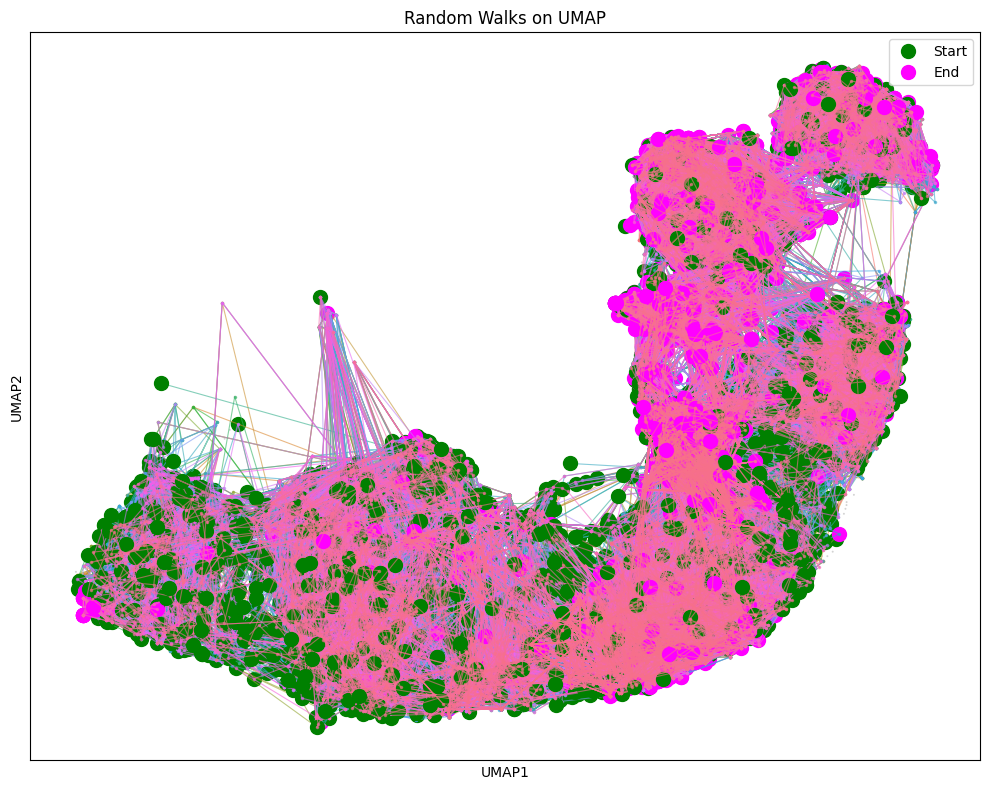

In [5]:
lsd.set_phylogeny(phylogeny, cluster_key="clusters")
lsd.set_prior_transition(prior_transition= P)
lsd.prepare_walks()
plot_random_walks(lsd.adata, lsd.walks, "X_umap")

Training Epochs: 100%|██████████| 100/100 [17:19<00:00, 10.39s/it, -ELBO=1.2557, Potential Metric=0.2070, Entropy Metric=0.0367]


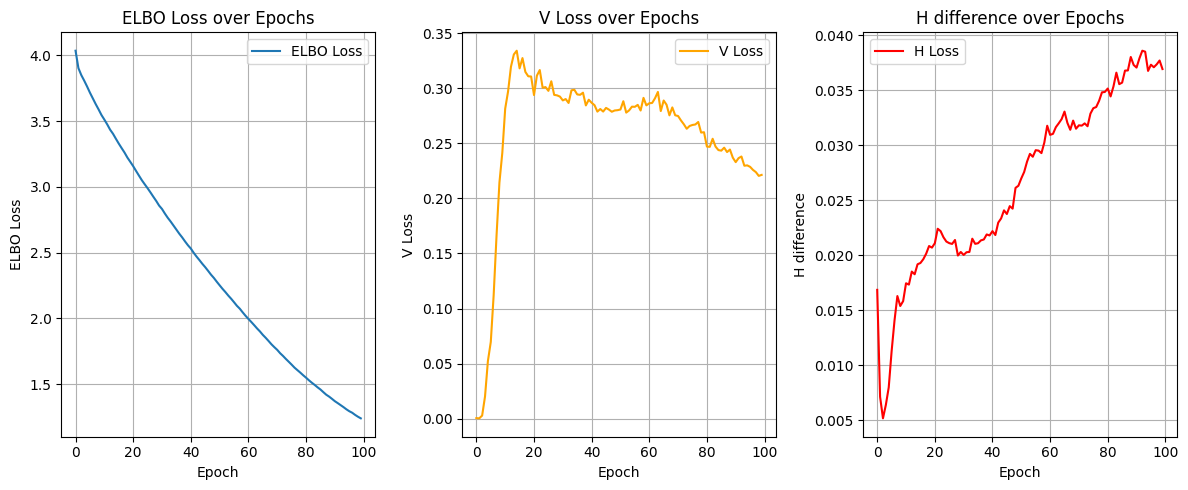

In [6]:
model_dir = "./model"
clear_pyro_state()
lsd.train(
    num_epochs=100,
    save_dir=model_dir,
    save_interval=50,  # Save checkpoints every 20 epochs
    random_state=SEED
)

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/sclsd/train/trainer.py:894: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predicted_fates = adata.obs[cluster_key][nn.cpu().numpy()].values


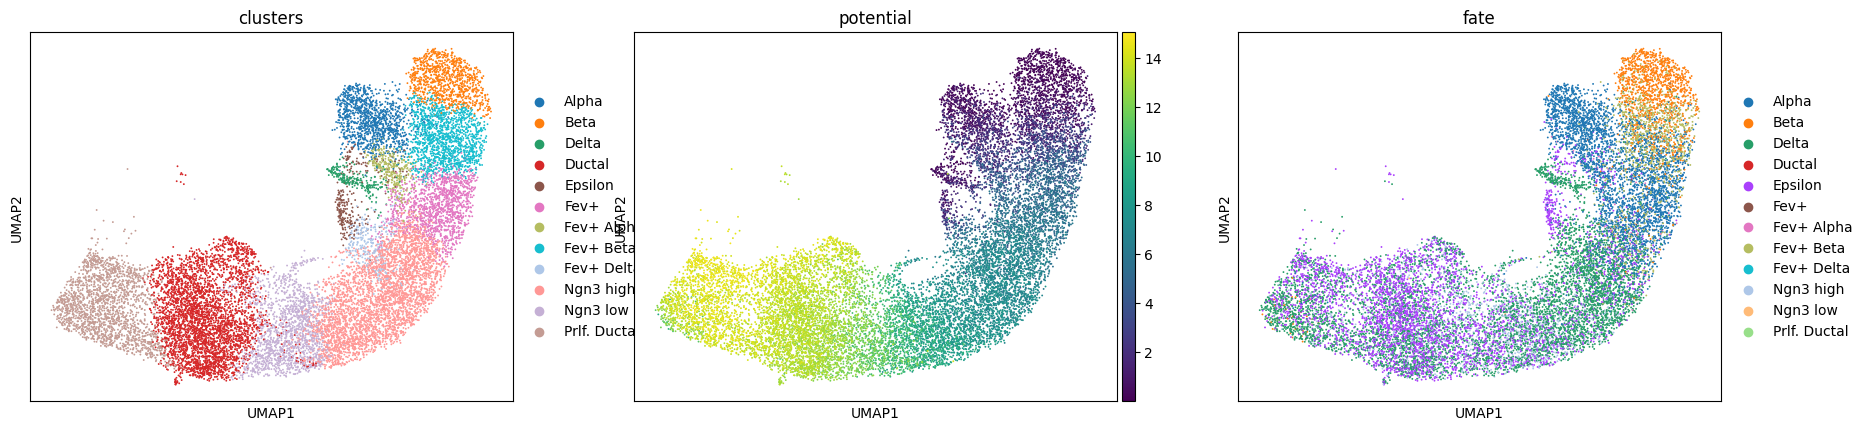

In [7]:
#get the predictions of loc model
lsd.set_adata(adata)
dyn_adata = lsd.get_cell_fates(lsd.get_adata(), time_range = 20 , cluster_key= "clusters", batch_size= 2048)
sc.pl.umap(dyn_adata, color = ["clusters", "potential", "fate"])

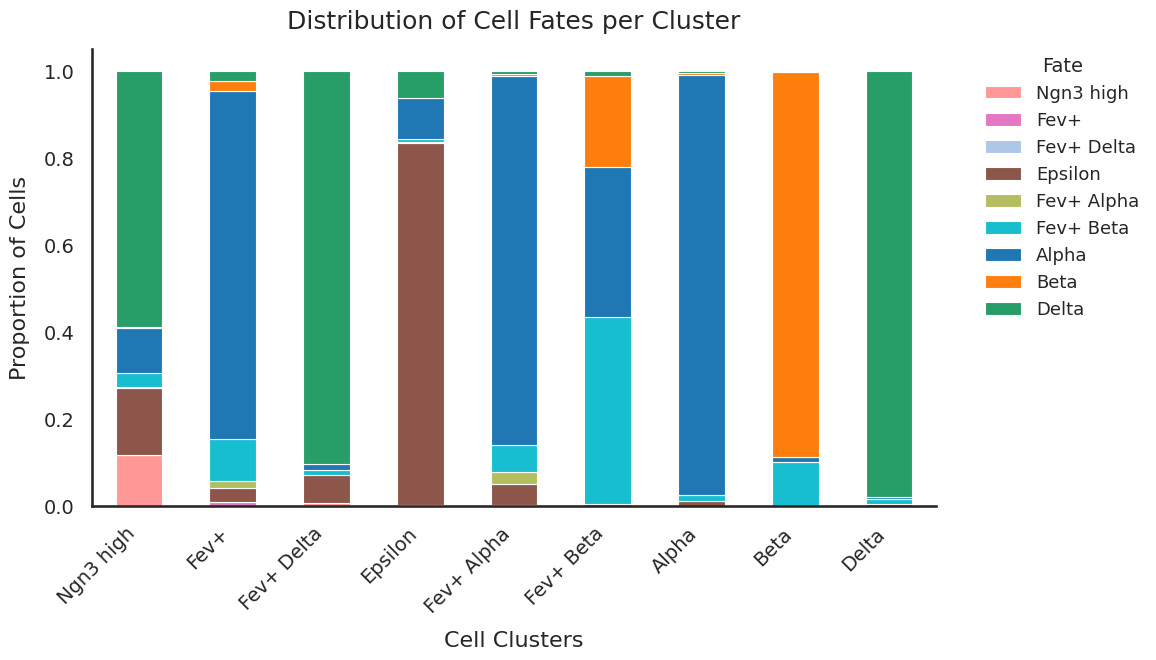

In [8]:
phylo = {
          'Ngn3 high':['Fev+','Fev+ Delta','Epsilon'],'Fev+':['Fev+ Alpha','Fev+ Beta'],
          'Fev+ Delta':['Delta'], 'Epsilon': [],'Fev+ Alpha':['Alpha'],
            'Fev+ Beta':['Beta'], 'Alpha':[], 'Beta':[], 'Delta':[]}

# Use a clean seaborn style without grid lines for an elegant look
sns.set_style("white")
sns.set_context("talk", font_scale=1.1)

# Define the desired order for clusters/fate
desired_order = list(phylo.keys())

# Ensure both "clusters" and "fate" columns are categorical.
dyn_adata.obs["clusters"] = dyn_adata.obs["clusters"].astype("category")
dyn_adata.obs["fate"] = dyn_adata.obs["fate"].astype("category")

# Create a contingency table (cell counts) with clusters as rows and fate as columns.
count_table = pd.crosstab(dyn_adata.obs["clusters"], dyn_adata.obs["fate"])

# Reorder rows (clusters) and columns (fate) using the desired order.
count_table = count_table.reindex(desired_order, fill_value=0)
count_table = count_table.reindex(columns=desired_order, fill_value=0)

# Convert counts to proportions (each row sums to 1)
p_table = count_table.div(count_table.sum(axis=1), axis=0)

# Build a color mapping using the clusters_color from the AnnData object.
# It's assumed dyn_adata.uns["clusters_color"] is a list of colors corresponding to the clusters.
cluster_categories = list(dyn_adata.obs["clusters"].cat.categories)
clusters_color = dyn_adata.uns["clusters_colors"]
color_mapping = dict(zip(cluster_categories, clusters_color))

# Create a list of colors for the fate segments, using the desired order.
fate_colors = [color_mapping[cat] for cat in desired_order]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the stacked bar chart using the proportions table.
p_table.plot(kind="bar", 
             stacked=True, 
             color=fate_colors, 
             ax=ax, 
             edgecolor='white', 
             linewidth=0.8)

# Set axis labels and title with proper naming
ax.set_xlabel("Cell Clusters", fontsize=16, labelpad=10)
ax.set_ylabel("Proportion of Cells", fontsize=16, labelpad=10)
ax.set_title("Distribution of Cell Fates per Cluster", fontsize=18, pad=15)

# Remove grid lines for a cleaner appearance
ax.grid(False)

# Adjust tick parameters for clarity
ax.tick_params(axis='both', which='major', labelsize=14)
plt.xticks(rotation=45, ha="right")

# Remove unwanted spines
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

# Place legend outside the plot for a neater presentation.
# Here, we position the legend to the upper right outside the axes.
leg = ax.legend(title="Fate", 
                bbox_to_anchor=(1.05, 1),  # adjust horizontal and vertical position
                loc='upper left', 
                borderaxespad=0,
                frameon=False,
                fontsize=13,
                title_fontsize=14)
                
# Tight layout for better spacing between plot elements.
plt.tight_layout()

plt.show()


/projects/apour/.cache/tmp/ipykernel_2931376/578176036.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Unseen Cell Type", y="Correct Fate Proportion", palette="muted", width= 0.5)


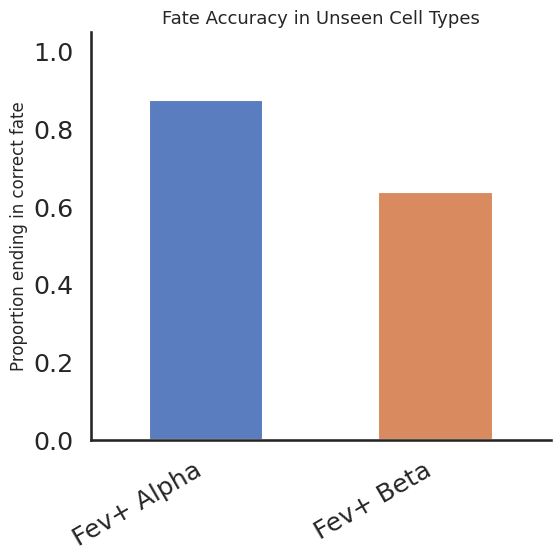

In [9]:
clust = {"Fev+ Alpha": ["Fev+ Alpha", "Alpha"], "Fev+ Beta": ["Fev+ Beta", "Beta"]}
freq = {}
for key in clust.keys():
    freq[key] = 0
    for value in clust[key]:
        freq[key] += p_table.loc[key][value]

# Convert to DataFrame for easier plotting
df = pd.DataFrame({
    "Unseen Cell Type": list(freq.keys()),
    "Correct Fate Proportion": list(freq.values())
})

# Plot settings
plt.figure(figsize=(6, 6))
sns.barplot(data=df, x="Unseen Cell Type", y="Correct Fate Proportion", palette="muted", width= 0.5)

# Aesthetic tweaks
plt.ylim(0, 1.05)
plt.ylabel("Proportion ending in correct fate", fontsize=12)
plt.xlabel("")
plt.title("Fate Accuracy in Unseen Cell Types", fontsize=13)
plt.xticks(rotation=30, ha="right")
sns.despine()

# Show plot
plt.tight_layout()
plt.show()